## Imports

In [5]:
from qsopt import * 
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax

## Define experimental parameters

In [24]:
gm = 0.03 * 2 * np.pi
inverse_pulse_width = 0.1 * gm

# Define custom physical constants
custom_constants = PhysicalConstants(
    chi = 0.5 * gm,                    # Dispersive coupling
    photon_cavity_coupling = gm,  # Photon-cavity coupling
    inverse_pulse_width = 0.1 * gm      # Inverse pulse width
)

# Define custom system dimensions
custom_dims = SystemDimensions(
    cavity_levels=2,
    qubit_levels=2,
    field_levels=2
)

# Define measurement protocol
custom_measurement = MeasurementProtocol(
    measurement_times = None,  # Use default measurement times
    initial_time=-8.0/inverse_pulse_width,
    final_time=8.0/inverse_pulse_width,
    time_interval=4.0/inverse_pulse_width,
    initial_time_uncertainty=1.5/inverse_pulse_width
)

# Define initial state configuration (SINGLE_PHOTON)
initial_state = InitialStateConfig(
    state_type=InitialStateType.SINGLE_PHOTON
)

# Define noise configuration
noise_config = NoiseConfiguration(
    depolarizing = 0.00,  
    dephasing = 0.000,      
    relaxation = 0.001
)

# Create parameters with custom configuration
exp_parameters = ExperimentalParameters(
    physical_constants=custom_constants,
    system_dims=custom_dims,
    measurement=custom_measurement,
    initial_state=initial_state,
    noise_config=noise_config
)

print(exp_parameters)

SYSTEM DIMENSIONS
  Cavity levels:             2
  Qubit levels:              2
  Field levels:              2
  Total dimension:           8
PHYSICAL CONSTANTS
  Chi:                    0.0942
  Photon cavity coupling: 0.1885
  Inverse pulse width:    0.0188
MEASUREMENT PROTOCOL
  Mode:                 Interval-based
  Initial time:         -424.4132
  Final time:           424.4132
  Time interval:        212.2066
  Number of measurements:      5
  Computed times:       [-424.4131815783876, -212.2065907891938, 0.0, 212.2065907891938, 424.4131815783876]
  Initial time uncertainty:  79.5775
INITIAL STATE
  Type:                 single_photon
NOISE MODEL
  Depolarizing rate:      0.0000
  Dephasing rate:         0.0000
  Relaxation rate:        0.0010
  Custom operators:     None
SYSTEM STATUS
  Configuration:        VALID


## Optional, plot pulse shape

Pulse shape plot saved to: pulse_shape.png


C:\Users\simon\AppData\Local\Temp\ipykernel_24200\3012061328.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


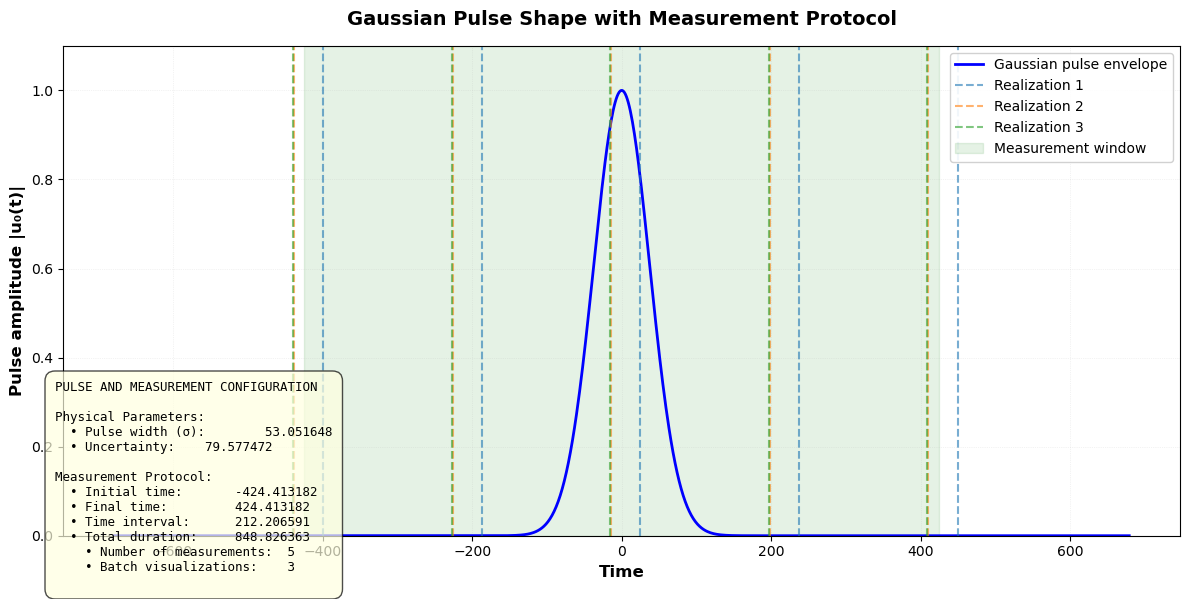

In [ ]:
from qsopt.utils.visualization import plot_pulse_shape_with_measurements

fig = plot_pulse_shape_with_measurements(
    exp_params=exp_parameters,
    save_path='results/pulse_shape.png',
    batch_size=3
)
fig.show()

## Define trainable parameters

In [26]:
parameters = TrainableParameters()
parameters.add_rotation_angles(['ry1', 'ry2'], [np.pi/2, -np.pi/2], optimizer=optax.sgd(0.5))

print(parameters)

Trainable Parameters: 2
  Rotation Angles:
    ry1: 1.5708 rad (90.00°)
    ry2: -1.5708 rad (-90.00°)


## Define experiment

In [27]:
experiment = SingleQubitExperiment(exp_parameters, parameters)

## Test Single Simulation

In [28]:
results = experiment.run_simulation()
print(results)

MODE: Single Simulation
  Current Parameters:
     ry1: 1.570796 rad (90.00°)
     ry2: -1.570796 rad (-90.00°)
  Detection Probabilities:
     P(with photon):    0.945029
     P(without photon): 0.186639
     Contrast:          0.758390


## Run Optimization

In [ ]:

# The experiment automatically uses its built-in callback (saves every epoch by default)
history = experiment.optimize_rotations(
    theta_init=[1.3, -1.3],
    num_steps=70,
    verbose=True,
    batch_size=10,
    tolerance=1e-7
)

Configuration:
    Max iterations: 70
    Batch size: 1
    Convergence tolerance: 1.00e-07
    Initial rotation parameters: ry1=1.300 rad, ry2=-1.300 rad
    Optimizer: GradientTransformationExtraArgs
    Measurement uncertainty: ±79.577
Step  ry1         ry2         Contrast    Grad Norm
----------------------------------------------------------------------
0     1.300000    -1.300000   0.764187    2.40e-01    
10    1.481383    -1.401694   0.781328    1.16e-03    
20    1.481617    -1.401087   0.787393    1.76e-03    
30    1.481431    -1.401208   0.788333    1.63e-03    
40    1.481413    -1.401188   0.778294    5.17e-04    
50    1.481910    -1.401640   0.789324    1.42e-03    
60    1.482043    -1.401915   0.780285    9.32e-04    
Final gradient norm: 7.55e-04
Best sensing contrast: 0.789464
Best parameters: ry1=1.482 rad, ry2=-1.402 rad


In [33]:
print(history)

MODE: Optimization
     Total iterations: 70
     Best epoch:        35
     Converged: False
     Final gradient norm: 7.549223e-04
  Best Parameters:
     ry1: 1.482251 rad (84.93°)
     ry2: -1.402167 rad (-80.34°)
  Detection Probabilities:
     P(with photon):    0.927183
     P(without photon): 0.137720
     Contrast:          0.789464


## Visualization Dashboard

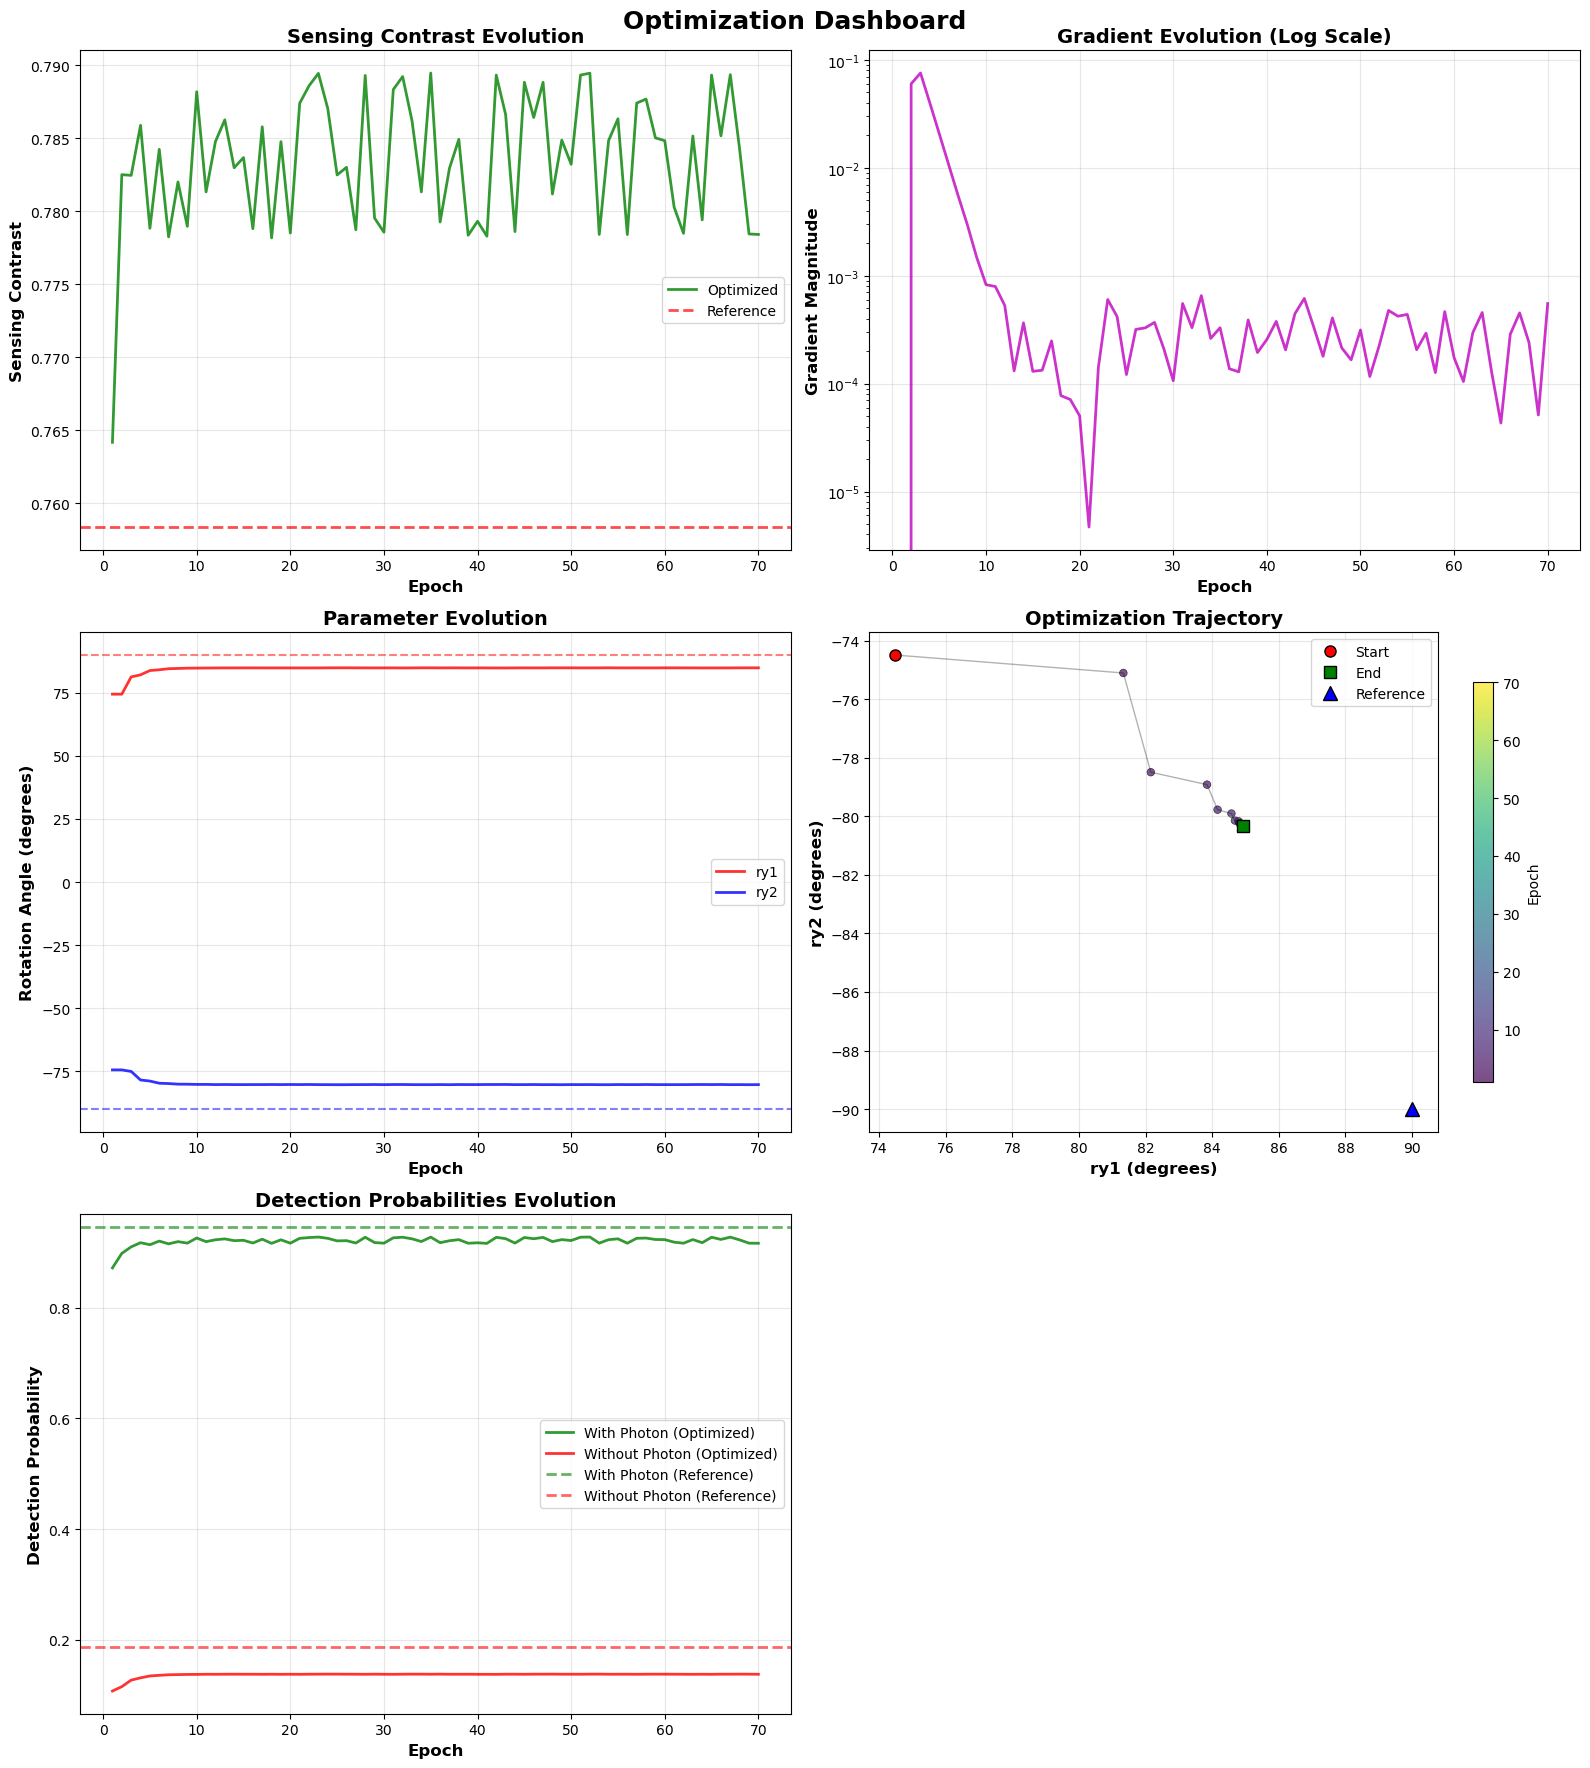

In [34]:
from qsopt.utils.visualization import plot_optimization_dashboard

# Create comprehensive dashboard with all plots enabled
fig = plot_optimization_dashboard(
    optimization_callback=history,
    reference_callback=results,
    show_contrast=True,
    show_gradients=True,
    show_parameters=True,
    show_trajectory=True,
    show_probabilities=True,
    save_path='results/opt_dashboard.pdf'  # Save to file
)

plt.show()

## Optimize Measurement Times